### I recommend you make a copy of the notebook and date it to keep the default one on handby 
### this also makes it easier to track the changes you make dependning on the experiments you're looking at 
#### note that this isn't 100% accurate and will sometimes give you channels for which cells were in the channels but could have left in the middle of the timelapse

In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np 
import tifffile


In [ ]:
exp_name = 'DUMM_baeS_gfcE_112025'
input_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/scope1dataQ_2/Adrian/DUMM_baeS_gfcE_112025/_1'
POS_LIST='["Pos4", "Pos5", "Pos11", "Pos12", "Pos16"]'
trench_ends = 'up'

In [ ]:
exp_name = 'DUMM_baeS_chpS_120425'
input_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/scope1dataQ_2/Adrian/DUMM_baeS_chpS_120425/_1'
POS_LIST='["Pos1", "Pos2", "Pos5", "Pos11", "Pos14", "Pos21", "Pos22"]'
trench_ends = 'up'

In [ ]:
exp_name = 'DUMM_giTG066_063_120925'
input_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/scope1dataQ_2/Adrian/DUMM_giTG066_063_120925/_1'
POS_LIST='["Pos2", "Pos3", "Pos7", "Pos12", "Pos18", "Pos19"]'
trench_ends = 'up'

In [ ]:
exp_name = 'DUMM_giTG069_063_121125'
input_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/scope1dataQ_2/Adrian/DUMM_giTG069_063_121125/_1'
POS_LIST='["Pos1", "Pos3", "Pos5", "Pos6", "Pos8", "Pos10", "Pos11", "Pos13", "Pos16", "Pos22","Pos25"]'
trench_ends = 'up'

In [ ]:
exp_name = 'DUMM_giTG069_063_121225'
input_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/scope1dataQ_2/Adrian/DUMM_giTG069_063_121225/_1'
POS_LIST='["Pos0", "Pos11", "Pos13", "Pos17", "Pos18", "Pos22"]'
trench_ends = 'up'

In [ ]:
exp_name = 'DUMM_giTG062_064_121325'
input_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/scope1dataQ_2/Adrian/DUMM_giTG062_064_121325/_1'
POS_LIST='["Pos4", "Pos5", "Pos10", "Pos12", "Pos15", "Pos18", "Pos19"]'
trench_ends = 'up'

In [ ]:
exp_name = 'DUMM_giTG060_064_121425'
input_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/scope1dataQ_2/Adrian/renamed/DUMM_giTG060_064_121425/_1'
POS_LIST='["Pos0", "Pos5", "Pos13", "Pos14", "Pos20", "Pos22"]'
trench_ends = 'up'

In [ ]:
exp_name = 'DUMM_giTG060_064_121425'
input_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/scope1dataQ_2/Adrian/renamed/DUMM_mazF_murQ_121625/_1'
POS_LIST='["Pos5", "Pos6", "Pos12", "Pos16", "Pos17", "Pos18"]'
trench_ends = 'up'

### Here you should put in your own input paths, the first two are just exmple formats of where everything should be saved
### Make sure that the CSV FOV # matches the FOV # of the tif file you're analyzing 

In [2]:
# example of how to write out your paths 
csv_input_path_example = './EXP_NAME_DIR/hyperstacked/drift_corrected/rotated/mm_channelsFOVXYZ.csv"20250815_GNN_train_cell_lineage.ipynb'
rotated_tiff_path_example = './EXP_NAME_DIR/hyperstacked/drift_corrected/rotated/rotated_drift_cor_DuMM_xyFOV.tif'

In [14]:
# replace these with your paths 
csv_path = "/Volumes/mcovert/Instruments/Covert-lab-scope1/scope1dataQ_2/Adrian/DUMM_baeS_gfcE_112025/_1/hyperstacked/drift_corrected/rotated/mm_channelsFOV011.csv"
rotated_tif_path = "/Volumes/mcovert/Instruments/Covert-lab-scope1/scope1dataQ_2/Adrian/DUMM_baeS_gfcE_112025/_1/hyperstacked/drift_corrected/rotated/rotated_drift_cor_DuMM_xy011.tif"

In [15]:
# loads images into ndarrays and csv into pandas dataframe
trench_ids = pd.read_csv(csv_path)
image = tifffile.imread(rotated_tif_path)
phase_stack = image[:,0,:,:]
fluor_stack = image[:,1,:,:]


In [16]:
# bottom and top pixels of image mess with normalization and averages
y_length = phase_stack.shape[1]  
y_start = int(0.1 * y_length)  
y_end = int(0.9 * y_length)  
# drift correct crop can also impact edge x pixels

x_length = phase_stack.shape[2]  
x_start = int(0.1 * y_length) 
x_end = int(0.9 * y_length)  

#normalizing using values from a cropped tiff file 
cropped_min_val = np.min(phase_stack[:, y_start:y_end, x_start:x_end])
cropped_max_val = np.max(phase_stack[:, y_start:y_end, x_start:x_end])
if cropped_max_val > cropped_min_val:
    normalized_phase_stack = (phase_stack - cropped_min_val) / (cropped_max_val - cropped_min_val)
else:
    print("All values in phase_stack are the same. Normalization will not change the data.")

In [17]:
average_intensity = []  

for idx, row in trench_ids.iterrows():
    trench = row[0]  
    x = row[1]     
    
    # check that x pixel is inside the image 
    if 0 <= x < normalized_phase_stack.shape[2]:
        intensity_values = normalized_phase_stack[:, :, x+6] # pixel saved is slightly left of middle of channel
        intensity_values_middle = intensity_values[:, y_start:y_end]
        avg_int = np.min(intensity_values_middle, axis=0)  # find the minimum of each timepoint 
        
        final_avg_intensity = np.mean(avg_int)  # Further average over y dimension
        average_intensity.append((trench, final_avg_intensity))  # Store trench and avg intensity
    else:
        average_intensity.append((trench, None))  # Append None for out-of-bounds trench

# Convert results to a DataFrame
results_df = pd.DataFrame(average_intensity, columns=['trench_id', 'avg_int'])  # Store trench_id instead of channel_id

# Step 4: Determine empty and non-empty trenches based on a threshold
threshold = 0.25  # Example threshold (adjust as necessary)

results_df['has_cells'] = results_df['avg_int'].apply(lambda x: x is None or x < threshold)

#Display results
print(results_df)

    trench_id   avg_int  has_cells
0          93  0.300740      False
1         171  0.287090      False
2         247  0.311594      False
3         324  0.467148      False
4         400  0.367425      False
5         478  0.433978      False
6         555  0.367719      False
7         635  0.271444      False
8         711  0.377637      False
9         788  0.396961      False
10        864  0.306796      False
11        940  0.308938      False
12       1016  0.283584      False
13       1087  0.268986      False
14       1163  0.256910      False
15       1239  0.260958      False
16       1315  0.273489      False
17       1391  0.282098      False
18       1467  0.287628      False
19       1543  0.284002      False
20       1619  0.283812      False
21       1695  0.298503      False
22       1771  0.293774      False
23       1847  0.303621      False
24       1923  0.305542      False
25       1999  0.309385      False
26       2075  0.315617      False


/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_34591/2738094193.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  trench = row[0]
/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_34591/2738094193.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = row[1]


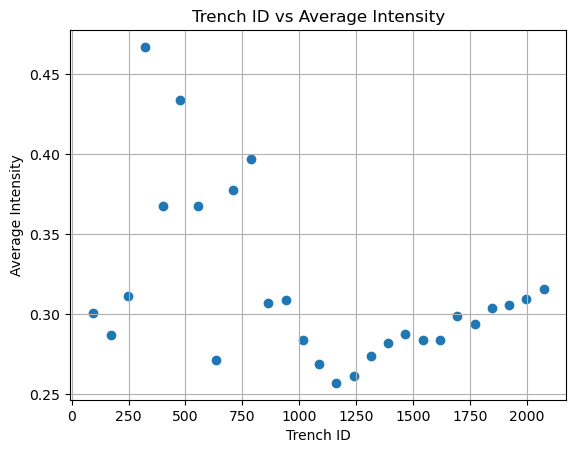

In [18]:
filtered_results = results_df[results_df['avg_int'].notna()]
plt.scatter(results_df['trench_id'], filtered_results['avg_int'])

plt.title('Trench ID vs Average Intensity')
plt.xlabel('Trench ID')
plt.ylabel('Average Intensity')
plt.grid(True)

### Here the print output should be in the format needed to run 02_background_subtraction
### you will need to pick out an empty trench yourself but you can see the list above for any example 
function 2 only does 1 FOV at a time so no need to try and find everything at once 

In [19]:
cell_trenches = results_df[results_df['has_cells']]
anna_peak_ids = " ".join(f"'{int(trench_id)}'" for trench_id in cell_trenches['trench_id'])
print(anna_peak_ids)